正在加载 Shift=1 的所有 Level 数据...
正在绘制云雨图...


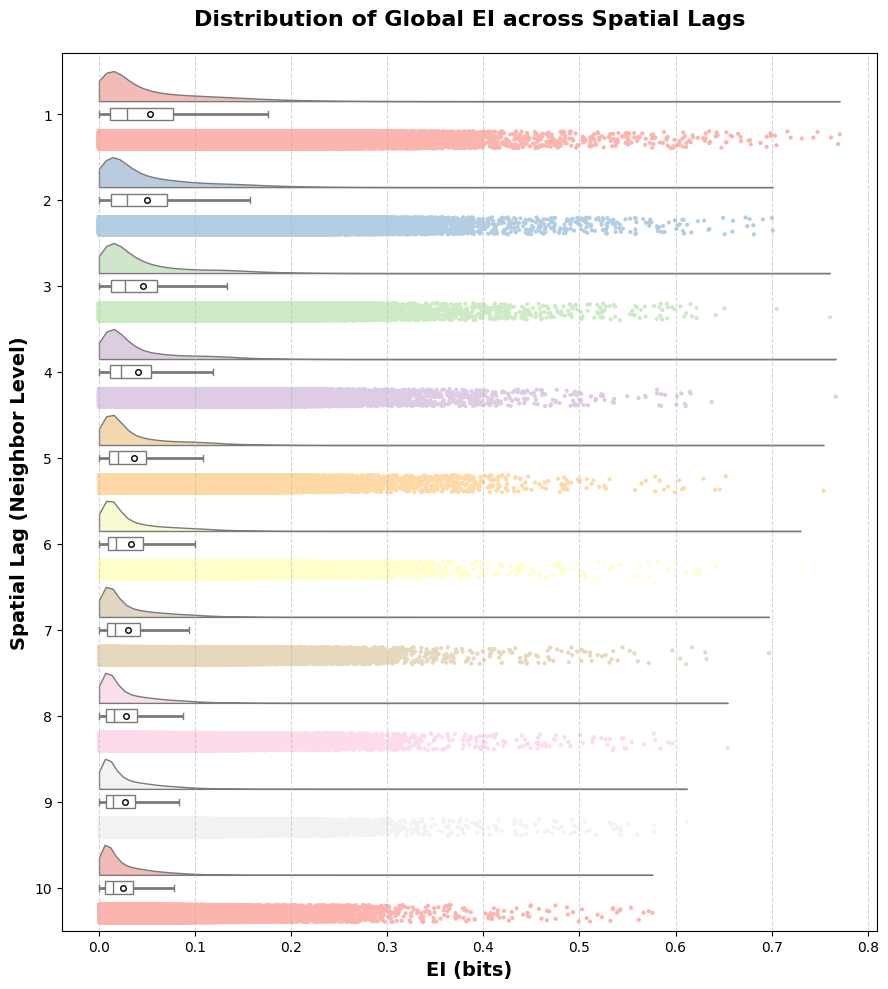

云雨图已保存: figure_raincloud_paper/raincloud_shift_1_window1.png


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt 
import config as cfg

# ————————————————————————
# 配置
# ————————————————————————
TARGET_SHIFT = 1
LEVEL=10
OUTPUT_DIR = "figure_raincloud_paper"
os.makedirs(OUTPUT_DIR, exist_ok=True)
MATRIX_PATH="matrix_te_avg_pairwise_1"
def load_data_for_shift(target_shift):
    print(f"正在加载 Shift={target_shift} 的所有 Level 数据...")
    
    data_list = []
    
    # 遍历所有 Level
    for level in range(1, LEVEL + 1):
        # 构建文件名: te_map_level_{level}_shift_{shift}.npy
        file_name = f"te_map_level_{level}_shift_{target_shift}.npy"
        file_path = os.path.join(MATRIX_PATH, file_name)
        
        if os.path.exists(file_path):
            try:
                # 读取数据矩阵
                mi_map = np.load(file_path)
                
                # 展平并移除 NaN
                values = mi_map.flatten()
                valid_values = values[~np.isnan(values)]
                
                # 为了绘图性能，如果数据量太大(例如百万级)，可以随机降采样
                # 假设全球格点约 10000 个，通常不需要降采样
                # 但如果为了绘图速度，可以保留前 5000 个点
                # if len(valid_values) > 10000:
                #     valid_values = np.random.choice(valid_values, 10000, replace=False)
                
                # 添加到列表
                for v in valid_values:
                    data_list.append({'Level': level, 'EI': v})
                    
            except Exception as e:
                print(f"读取 Level {level} 出错: {e}")
        else:
            # print(f"文件缺失: {file_name}")
            pass
            
    return pd.DataFrame(data_list)

def plot_raincloud(df):
    if df.empty:
        print("没有数据可绘图。")
        return

    print("正在绘制云雨图...")
    
    # 设置画布
    # 宽度根据 Level 数量动态调整，确保不拥挤
    # fig_width = max(20, LEVEL * 1.2)
    # f, ax = plt.subplots(figsize=(fig_width, 8))

    fig_length=max(10, LEVEL * 1)
    fig, ax = plt.subplots(figsize=(9, fig_length))
    # 定义配色 (使用渐变色表示 Level 递增)
    # 'viridis', 'plasma', 'coolwarm' 都是不错的选择
    palette = sns.color_palette("Pastel1", n_colors=LEVEL)

    # ——————————————————————————————————————————————
    # 定义对称参数
    # ——————————————————————————————————————————————
    # 核心技巧：
    # 1. 箱体宽度 (BOX_WIDTH) 要小于 2 * SHIFT_DIST，否则会遮挡。
    # 2. 设置 move = SHIFT_DIST (雨向下移)
    # 3. 设置 offset = SHIFT_DIST (云向上移)

    # 绘制云雨图
    pt.RainCloud(
        # === 基础设置 ===
        data=df, 
        x="Level",              # 分组变量 (按照您的要求：x=Level)
        y="EI",                 # 数值变量 (按照您的要求：y=EI)
        orient='h',             # 横向模式 (ptitprince 会自动处理 x/y 翻转)
        ax=ax,
        palette=palette,
        hue="Level",           # 必须指定 hue，防止 Seaborn 报错
        
        # # === 1. 云 (Cloud / Violin) 参数 ===
        # # 控制密度图
        # bw=0.2,                 # 平滑度
        # width_viol=0.7,         # 云的厚度
        # cut=0,                  # 截断
        offset=0.15,      # 【关键】手动指定云的偏移量，使其与雨对称
        
        # # === 2. 伞 (Boxplot / Box) 参数 ===
        # # 控制箱线图
        # width_box=BOX_WIDTH,    # 箱体宽度 (设窄一点，居中)
        # box_linewidth=1.2,      # 边框粗细
        box_showfliers=False,   # 不显示异常值
        box_showmeans=True,     # 显示均值点
        # 均值点样式 (加 box_ 前缀)
        box_meanprops={
            "marker": "o", 
            "markerfacecolor": "white", 
            "markeredgecolor": "black", 
            "markersize": 4
        },
        
        # # === 3. 雨 (Rain / Stripplot) 参数 ===
        # # 控制散点图
        # point_plot=True,        # 显示均值连线
        # point_size=1.5,         # 散点大小
        # alpha=0.6,              # 散点透明度
        # dodge=True,             # 避让
        # jitter=0.35,            # 抖动幅度
        move=0.3         # 【关键】手动指定雨的偏移量，必须等于 offset
    )

    # 美化
    # ax.set_title(f"Distribution of Global EI at Lag {TARGET_SHIFT} across Spatial Scales", 
    #              fontsize=16, fontweight='bold', pad=20)
    ax.set_title(f"Distribution of Global EI across Spatial Lags", 
            fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel("Spatial Lag (Neighbor Level)", fontsize=14, fontweight='bold')
    ax.set_xlabel("EI (bits)", fontsize=14, fontweight='bold')
    
    # 设置 X 轴刻度 (确保显示所有整数 Level)
    ax.set_yticks(range(LEVEL))
    ax.set_yticklabels(range(1, LEVEL + 1), fontsize=10)
    
    # 添加网格线
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    # # 去除顶部和右侧边框
    # sns.despine()

    # 保存
    save_path = os.path.join(OUTPUT_DIR, f"raincloud_shift_{TARGET_SHIFT}_window1.png")
    plt.tight_layout()
    fig.savefig(save_path, dpi=300)
    plt.show()
    plt.close()
    
    print(f"云雨图已保存: {save_path}")

if __name__ == "__main__":
    # 1. 加载数据
    df = load_data_for_shift(TARGET_SHIFT)
    
    # 2. 绘图
    plot_raincloud(df)

=== 开始可视化单帧分布图 ===
目标: Level 10, Shift 1
数据加载成功. 形状: (721, 1440)
全图均值: 0.0253 bits | 最大值: 0.5761 bits


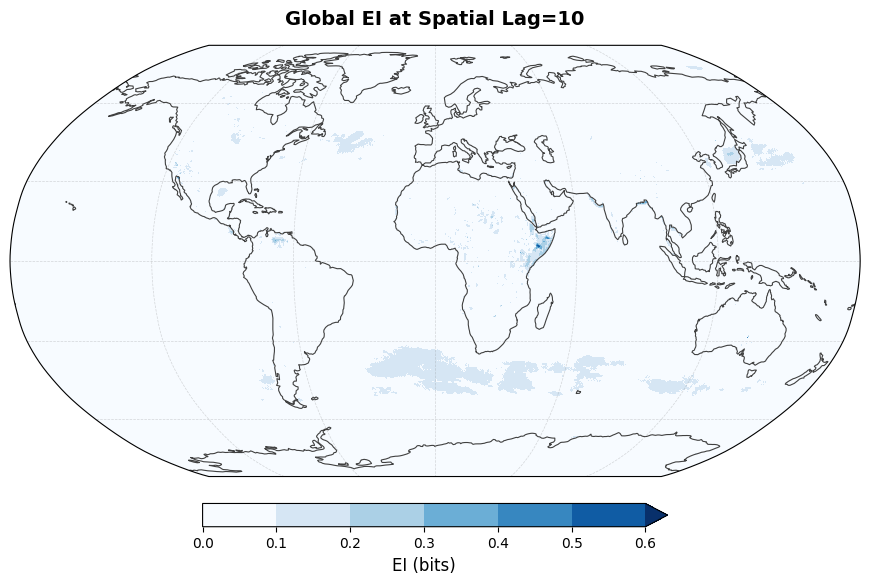

图片已保存至: figure_single_visualization/viz_level10_shift1_builtin.png


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import config as cfg  # 只需要读取路径配置，不需要计算模块

# ——————————————————————————————————————————————
# 1. 配置参数 (请在此处修改您想看的目标)
# ——————————————————————————————————————————————
# 数据存放目录 (需与 main.py 的 MATRIX_PATH 一致)
DATA_DIR = "matrix_te_avg_pairwise_1" 
OUTPUT_DIR = "figure_single_visualization"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 【核心设置】选择您要可视化的具体组合
TARGET_LEVEL = 10    # 空间阶数 (Level)
TARGET_SHIFT = 1    # 时间滞后 (Shift/Lag)

# 文件名模式 (对应 main.py 生成的格式)
FILE_PATTERN = "te_map_level_{level}_shift_{shift}.npy"

# ——————————————————————————————————————————————
# 2. 配色方案 (修改为使用系统色带)
# ——————————————————————————————————————————————
def get_colormap_config():
    """
    配置系统自带的色带，并使其离散化。
    """
    # 1. 选择系统色带名称
    # 推荐: 'turbo' (彩虹增强版), 'viridis' (蓝绿黄), 'plasma' (紫红黄), 'Spectral_r' (红黄蓝)
    cmap_name = 'Blues' 
    
    # 2. 定义分界点 (根据您的 EI 值域调整)
    # 这些数值定义了颜色的分段
    levels = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
    
    # 3. 获取系统色带
    # 我们需要从连续色带中提取出对应数量的颜色块
    # 基础区间有 len(levels) - 1 个
    # 因为我们要 extend='max' (超过0.8的部分显示为一种颜色)，所以需要多取一个颜色
    n_colors = len(levels) - 1 + 1 
    
    # plt.get_cmap(name, n) 会自动把连续色带切分成 n 个离散颜色
    cmap = plt.get_cmap(cmap_name, n_colors)
    
    # 4. 创建 BoundaryNorm
    # 这确保了数值准确落入对应的颜色块中
    norm = mcolors.BoundaryNorm(levels, ncolors=n_colors, extend='max')
    
    return cmap, norm

# ——————————————————————————————————————————————
# 3. 绘图主逻辑
# ——————————————————————————————————————————————
def visualize_single_map():
    print(f"=== 开始可视化单帧分布图 ===")
    print(f"目标: Level {TARGET_LEVEL}, Shift {TARGET_SHIFT}")
    
    # 1. 构建文件路径
    file_name = FILE_PATTERN.format(level=TARGET_LEVEL, shift=TARGET_SHIFT)
    file_path = os.path.join(DATA_DIR, file_name)
    
    if not os.path.exists(file_path):
        print(f"【错误】找不到数据文件: {file_path}")
        print(f"请检查:\n1. main.py 是否运行完成？\n2. DATA_DIR 设置是否正确？\n3. Level/Shift 是否超出计算范围？")
        return

    try:
        # 2. 读取数据
        mi_map = np.load(file_path)
        
        # 简单清洗: 负值归零 (仅用于绘图美观)
        mi_map[mi_map < 0] = 0
        
        # 计算统计量
        global_avg = np.nanmean(mi_map)
        max_val = np.nanmax(mi_map)
        print(f"数据加载成功. 形状: {mi_map.shape}")
        print(f"全图均值: {global_avg:.4f} bits | 最大值: {max_val:.4f} bits")
        
        # 3. 准备经纬度网格
        # 假设数据是标准 ERA5 网格 (Lat: 90->-90, Lon: 0->360)
        nlat, nlon = mi_map.shape
        lats = np.linspace(90, -90, nlat)
        lons = np.linspace(0, 360, nlon)
        
        # 4. 创建画布 (Robinson 投影, 非洲居中)
        fig = plt.figure(figsize=(12, 7))
        proj = ccrs.Robinson(central_longitude=0)
        ax = fig.add_subplot(1, 1, 1, projection=proj)
        
        # 获取配色
        cmap, norm = get_colormap_config()
        
        # 5. 绘制热力图
        im = ax.pcolormesh(lons, lats, mi_map,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap,
                           norm=norm)
        
        # 6. 添加地理要素
        # 海岸线 (深灰色，清晰但不抢眼)
        ax.coastlines(resolution='110m', linewidth=0.8, color='#404040')
        # # 国界线 (可选，淡灰色)
        # ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='gray', alpha=0.5)
        
        # 经纬网格线 (每 60 度一根)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                          linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
        gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))
        
        # 7. 色条与标题
        # 色条放在下方
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.5, pad=0.05,
                            spacing='uniform', extend='max')
        cbar.set_label('EI (bits)', fontsize=12)
        
        # 标题: 清晰展示参数
        # plt.title(f"Global Information Flow Distribution\n"
        #           f"Level={TARGET_LEVEL} (Spatial) | Lag={TARGET_SHIFT} (Temporal)\n"
        #           f"Global Avg = {global_avg:.4f} bits", 
        #           fontsize=14, fontweight='bold', pad=15)
        plt.title(f"Global EI at Spatial Lag={TARGET_LEVEL}",
                  fontsize=14, fontweight='bold', pad=15)
        # 8. 保存
        save_name = f"viz_level{TARGET_LEVEL}_shift{TARGET_SHIFT}_builtin.png"
        save_full_path = os.path.join(OUTPUT_DIR, save_name)
        
        plt.savefig(save_full_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"图片已保存至: {save_full_path}")
        
    except Exception as e:
        print(f"绘图过程中发生错误: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    visualize_single_map()